# Downloading JWST and Euclid data

In [1]:
import requests
import os
from io import BytesIO
from astropy.io import fits
import matplotlib.pyplot as plt
import dropbox
import numpy as np
import pandas as pd
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
from astropy.coordinates import SkyCoord
from astropy.nddata import Cutout2D
import warnings
from astropy.wcs import FITSFixedWarning
from scipy import ndimage

In [2]:
warnings.simplefilter('ignore', FITSFixedWarning)

In [3]:
# Links to shared folders
parent_url = 'https://www.dropbox.com/scl/fo/eo3ktfmhniyqm7l32egp4/AK5SQfnqsfDYbqvUW1WVESI?rlkey=enfshikpl0r0wd8o2nz66i0km&e=1&st=brev767o&dl=0'
jwst_url = 'https://www.dropbox.com/scl/fo/eo3ktfmhniyqm7l32egp4/ANfH2VisN0vIphVxNIpO_ag/JWST?rlkey=enfshikpl0r0wd8o2nz66i0km&subfolder_nav_tracking=1&st=w3u4yz80&dl=0'
nisp_url = 'https://www.dropbox.com/scl/fo/eo3ktfmhniyqm7l32egp4/AEiIbqfbMKqh6FRA2YouLHQ/NISP-J?rlkey=enfshikpl0r0wd8o2nz66i0km&subfolder_nav_tracking=1&st=hx3ru322&dl=0'

# Catalog files
farmer_cat_path = '../catalog/COSMOS2020_FARMER_R1_v2.2_p3.fits'
classic_cat_path = '../catalog/COSMOS2020_CLASSIC_R1_v2.2_p3.fits'

# Data files
np_jwst_file = '../data/jwst_data_66px.npy'
np_nisp_file = '../data/nisp_data_40px.npy'

In [4]:
def get_shared_folder_metadata(url, dbx):
    """Get metadata of the shared folder."""
    shared_link = dropbox.files.SharedLink(url=url)
    try:
        folder_metadata = dbx.files_list_folder(path="", shared_link=shared_link)
        return folder_metadata.entries
    except dropbox.exceptions.ApiError as e:
        print(f"Error accessing shared folder: {e}")
        return []

def get_fits_file(url, file_name, dbx):
    meta, res = dbx.sharing_get_shared_link_file(url, path='/'+file_name)

    fits_file = BytesIO(res.content)
    hdul = fits.open(fits_file)

    # Access image data
    image_data = hdul[0].data
    image_header = hdul[0].header
    hdul.close()
    return image_header, image_data

def cut_catalog(cat_file=classic_cat_path, cuts=None):
    # Open cat file
    with fits.open(classic_cat_path) as hdul:
        cat_data = hdul[1].data  # Adjust the HDU index if your data is not in the first extension
    
    # Do cuts on catalog data
    if cuts is None:
        cuts = (cat_data.lp_type==0) & \
                (cat_data.ACS_F814W_MAG < 25) & \
                (cat_data.ez_z_phot > 0.01) & (cat_data.ez_z_phot < 3.0) & \
                (cat_data.FLUX_RADIUS < 24) # TODO: make this a function with J&H bands?
    
    cat_clipped = cat_data[cuts]
    
    my_cat = pd.DataFrame({'id_classic': cat_clipped['ID'].astype(int),
                           'ra': cat_clipped['ALPHA_J2000'].astype(float),
                           'dec': cat_clipped['DELTA_J2000'].astype(float),
                           'jwst_image': "",
                           'nisp_image': "",
                          })
    
    return my_cat

def match_catalog(url, file_name, gal_coords, dbx):
    # Open FITS file
    image_header, image_data = get_fits_file(url, file_name, dbx=dbx)
    wcs = WCS(image_header)
    
    return np.where(gal_coords.contained_by(wcs))[0]

def rotate_jwst(clip, angle=-20, size=66, pad=20):
    if not clip.data.shape[0]>=size+pad:
        raise ValueError("Clip size is too small to rotate, make clips larger and then crop")
    # There are different types of interpolation possible for this one, talk about it with Shooby
    new_image = ndimage.rotate(clip.data, angle, reshape=False, cval=-20)
    new_clip = Cutout2D(new_image, clip.center_cutout, size)
    return new_clip # no WCS info after this

def clip_images(catalog, dbx, size_jwst=66, size_nisp=40, pad=20):
    ### The catalog must have matched ra, dec, jwst_image, and nisp_image columns
    image_pairs = my_cat.groupby(['jwst_image', 'nisp_image'])

    clips = []
    for pair, cat in image_pairs:
        jwst_file, nisp_file = pair
        
        # Open JWST and Euclid images
        jwst_header, jwst_data = get_fits_file(jwst_url, jwst_file, dbx=dbx)
        nisp_header, nisp_data = get_fits_file(nisp_url, nisp_file, dbx=dbx)
        wcs_jwst, wcs_nisp = WCS(jwst_header), WCS(nisp_header)
        
        # Get the coordinates of matched galaxies
        gal_coords = SkyCoord(cat.ra, cat.dec, unit='deg')
        
        for i in range(len(cat)):
            gal = cat.iloc[i]
            # Get JWST clip (larger than final size)
            clip_jwst = Cutout2D(jwst_data, gal_coords[i], size=size_jwst+pad, wcs=wcs_jwst, mode='trim')
            if sum(clip_jwst.data.shape)!=(size_jwst+pad)*2: continue
            
            # Get NISP clip
            clip_nisp = Cutout2D(nisp_data, gal_coords[i], size=size_nisp, wcs=wcs_nisp, mode='trim')
            if sum(clip_nisp.data.shape)!=(size_nisp)*2: continue
            
            # Rotate JWST image 20 degrees counter-clockwise and crop
            # This loses the WCS
            clip_jwst = rotate_jwst(clip_jwst, size=size_jwst)
            
            clips.append((gal_coords[i], clip_jwst, clip_nisp))

    return clips

In [5]:
# ### Uncomment next three blocks to remake the catalog and data files
# # Authenticate dropbox
# # Go to https://www.dropbox.com/developers/apps?_tk=pilot_lp&_ad=topbar4&_camp=myapps and generate new token,
# #    then copy and paste the token to a file of your choice, or directly to this cell
# with open("../../secrets/dropbox_token") as token_file:
#     token = token_file.read()
#     dbx = dropbox.Dropbox(token.strip())

# jwst_files = get_shared_folder_metadata(jwst_url, dbx=dbx)
# nisp_files = get_shared_folder_metadata(nisp_url, dbx=dbx)

In [6]:
# # Make the clipped catalog:
# my_cat = cut_catalog()
# gal_coords = SkyCoord(my_cat.ra, my_cat.dec, unit='deg')

# # Sort through and match JWST images
# for file in jwst_files:
#     found_idxs = match_catalog(jwst_url, file.name, gal_coords)
#     my_cat.loc[found_idxs, 'jwst_image'] = str(file.name)

# # Sort through and match Euclid images
# for file in nisp_files:
#     found_idxs = match_catalog(nisp_url, file.name, gal_coords)
#     my_cat.loc[found_idxs, 'nisp_image'] = str(file.name)

# my_cat = my_cat[my_cat.nisp_image!='']
# my_cat = my_cat[my_cat.jwst_image!='']
# my_cat.to_csv("../catalog/match_catalog.dat", index=False)

In [7]:
# # Save the clipped images
# try: my_cat
# except: my_cat = pd.read_csv('../catalog/match_catalog.csv')
# clips = clip_images(my_cat, dbx=dbx)

# # Arrange data
# jwst_cutouts = np.array([clip[1].data for clip in clips])
# nisp_cutouts = np.array([clip[2].data for clip in clips])

# # Save files
# np.save(np_jwst_file, jwst_cutouts, allow_pickle=False)
# np.save(np_nisp_file, nisp_cutouts, allow_pickle=False)

In [8]:
# Load data files
jwst_cutouts = np.load(np_jwst_file)
nisp_cutouts = np.load(np_nisp_file)

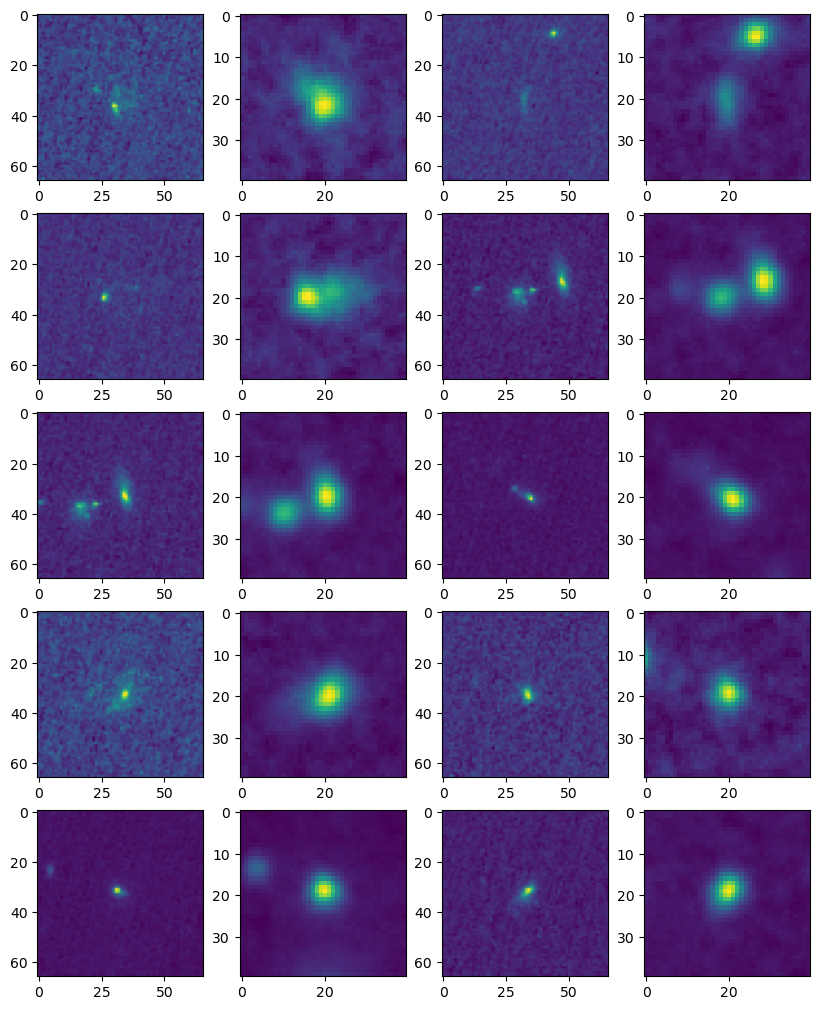

In [9]:
# Plotting images for verification purposes
n_rows = 5
fig, axes = plt.subplots(n_rows, 4, figsize=(10,2.5*n_rows))
for i in range(n_rows*2):
    clip_jwst = jwst_cutouts[i]
    clip_nisp = nisp_cutouts[i]
    axes.flatten()[i*2].imshow(clip_jwst)
    axes.flatten()[i*2+1].imshow(clip_nisp)

In [10]:
# nisp_ps = 0.09999975642693848
# jwst_ps = 0.05999903327225375
# # center, center_1 = clip_nisp.wcs.pixel_to_world(40, 40), clip_nisp.wcs.pixel_to_world(41, 40)
# # center.separation(center_1).arcsecond # NISP is 0.1"/pixel, JWST is 0.06"/pixel
# nisp_ps / jwst_ps * 20 # = JWST image size = 33.33378922062828 pixels (rounding up to 34)
# # New NISP size = 40, so JWST size is 66 (rounded down)

In [11]:
# corners = np.array([[0,0],[0,size_nisp],[size_nisp,size_nisp],[size_nisp,0],[0,0]])
# # [[0, 0, size_nisp, size_nisp],[0, size_nisp, 0, size_nisp]]
# corner_coords = clip_nisp.wcs.pixel_to_world(corners[:,0], corners[:,1])
# jwst_corners = clip_jwst.wcs.world_to_pixel(corner_coords)
# plt.imshow(clip_jwst.data)
# plt.plot(jwst_corners[0], jwst_corners[1], 'r-')

# pt1 = np.array(jwst_corners)[:,1]
# pt2 = np.array(jwst_corners)[:,2]
# pt3 = np.array([x1+34,y1])

# plt.plot([pt1[0],pt3[0]],[pt1[1],pt3[1]], 'r--')
# v1 = pt2-pt1
# v2 = pt3-pt1
# mag_v1 = np.sqrt(np.dot(v1,v1))
# mag_v2 = np.sqrt(np.dot(v2,v2))
# mag_v1, mag_v2

# np.arccos(np.dot(v1,v2)/(mag_v1*mag_v2))*180/np.pi # Shooby was right! Almost exactly 20 degrees

In [12]:
# Some older reference info:
# N1, N2 = image_data.shape # Data is in Y, X format, so Y axis is 12455 and X axis is 9600
# # Corners for input into pixel_to_world are in X, Y format! (0,0), (9600,0), (0,12455), and (9600,12455)
# corners = np.array([[0, 0], [N1, 0], [0, N2], [N1, N2]])
# corners_sky = wcs.pixel_to_world(corners[:,1], corners[:,0])
# corners_sky

In [13]:
# Euclid NISP = 0.3 as/px # This is not right, it is actually 0.1"/pixel
# JWST NIRCAM = 0.06 as/px
# Can do 100/20 px (exact ratio) or 128/24 px (less exact but might be better round numbers for GAN)

# Starting on the SR GAN

In [1]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import time
import random

In [2]:
jwst_file = "../data/jwst_data_66px.npy"
nisp_file = "../data/nisp_data_40px.npy"

In [3]:
tfms = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

def transform_data(img_data, tiny=1e-8):
    # Flattens higher values
    img_data = np.arcsinh(img_data)
    
    # Normalize to [0,1]
    img_data = (img_data - img_data.min()) / (img_data.max() - img_data.min() + tiny)
    # Can this normalization be reversed without knowing what the max / min values were?
    
    # Transform
    return tfms(img_data.astype(np.float32))  # Convert properly

In [4]:
np.random.seed(42)
class SuperResolutionDataset(Dataset):
    def __init__(self, lr_path, hr_path=None, transform=None, inference_mode=False, 
                 split='train', sample_fraction=1.0):
        """
        Dataset that loads LR images and optionally HR images.

        :param lr_hdf5_path: Path to Low-Resolution numpy file
        :param hr_hdf5_path: Path to High-Resolution numpy file (optional)
        :param transform: Optional torchvision transforms
        :param inference_mode: If True, returns only LR images (for super-res inference)
        """
        self.lr_path = lr_path
        self.hr_path = hr_path  # Can be None
        self.transform = transform
        self.split = split
        self.inference_mode = inference_mode  # If True, load only LR

        # Load keys from LR file
        self.lr_data = np.load(self.lr_path, mmap_mode='r')
        # Using self.keys as indices
        self.keys = np.arange(self.lr_data.shape[0])
        
        # TODO: Ask Shooby what percentage she wants in train/test split
        if self.split=='train': # Take 80%
            N = int(len(self.keys) * 0.8)
            self.keys = np.random.choice(self.keys, N, replace=False)
        else: # Take 20%
            N = int(len(self.keys)*0.2)
            self.keys = np.random.choice(self.keys, N, replace=False)
        
        # Subsample the dataset
        if sample_fraction < 1.0:
            num_samples = int(len(self.keys) * sample_fraction)
            self.keys = np.random.choice(self.keys, num_samples, replace=False)
        
        self.lr_data = self.lr_data[self.keys]

        # Check if HR exists
        self.has_hr = hr_path is not None
        if self.has_hr:
            self.hr_data = np.load(self.hr_path, mmap_mode='r')
            self.hr_data = self.hr_data[self.keys]
    
    def __len__(self):
        return len(self.lr_data)

    def __getitem__(self, idx):

        # Read one part of numpy array
        lr_image = transform_data(self.lr_data[idx])

        # Convert to tensor
        lr_image = torch.tensor(lr_image, dtype=torch.float32)

        # If in inference mode OR no HR data, return only LR image
        if self.inference_mode or not self.has_hr:
            return lr_image

        # Load HR image only if available
        hr_image = transform_data(self.hr_data[idx])
        hr_image = torch.tensor(hr_image, dtype=torch.float32)
        return lr_image, hr_image  # Training case (LR, HR)

In [5]:
# Load Training Dataset (for checking shape)
train_dataset = SuperResolutionDataset(nisp_file, jwst_file, split="train")
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# Get a batch for training
lr_batch, hr_batch = next(iter(train_loader))
print("Training Mode:")
print("LR Batch Shape:", lr_batch.shape)  # Expected: (16, 1, 40, 40)
print("HR Batch Shape:", hr_batch.shape)  # Expected: (16, 1, 66, 66)

# Load Test Dataset (for evaluation)
test_dataset = SuperResolutionDataset(nisp_file, jwst_file, split="test")
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Get a batch for inference (only LR images)
lr_batch, hr_batch = next(iter(test_loader))
print("Inference Mode:")
print("LR Batch Shape:", lr_batch.shape)  # Expected: (16, 1, 40, 40)
print("HR Batch Shape:", hr_batch.shape)  # Expected: (16, 1, 66, 66)

Training Mode:
LR Batch Shape: torch.Size([16, 1, 40, 40])
HR Batch Shape: torch.Size([16, 1, 66, 66])
Inference Mode:
LR Batch Shape: torch.Size([16, 1, 40, 40])
HR Batch Shape: torch.Size([16, 1, 66, 66])


/tmp/ipykernel_921346/2163081123.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  lr_image = torch.tensor(lr_image, dtype=torch.float32)
/tmp/ipykernel_921346/2163081123.py:62: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  hr_image = torch.tensor(hr_image, dtype=torch.float32)


In [6]:
# UNet with Cross-Attention
class SuperResDiffusionUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, hidden_dim=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, hidden_dim, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_dim, hidden_dim * 2, 3, padding=1, stride=2),
            nn.ReLU(),
            nn.Conv2d(hidden_dim * 2, hidden_dim * 4, 3, padding=1, stride=2),
            nn.ReLU(),
        )

        # Ensure condition matches x channels
        self.condition_proj = nn.Conv2d(1, hidden_dim * 4, kernel_size=3, padding=1)

        self.cross_attention = nn.MultiheadAttention(embed_dim=hidden_dim * 4, num_heads=4)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(hidden_dim * 4, hidden_dim * 2, kernel_size=3, stride=2, padding=1, output_padding=0),
            nn.ReLU(),
            nn.ConvTranspose2d(hidden_dim * 2, hidden_dim, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_dim, out_channels, kernel_size=3, padding=1),
        )

    def forward(self, x, condition):
        x = x.to(next(self.parameters()).device) 
        condition = condition.to(next(self.parameters()).device)

        x = self.encoder(x)
        condition = self.condition_proj(condition)

        batch_size, channels, height, width = x.shape

        # Flatten height & width dimensions before attention
        x = x.flatten(2).permute(2, 0, 1)
        condition = condition.flatten(2).permute(2, 0, 1)

        x, _ = self.cross_attention(x, condition, condition)

        # Reshape back to image format
        x = x.permute(1, 2, 0).view(batch_size, channels, height, width)
        x = self.decoder(x)
        return x

# Diffusion Model
class DiffusionModel(nn.Module):
    def __init__(self, unet_model, timesteps=100):
        super().__init__()
        self.unet = unet_model
        self.timesteps = timesteps

    def forward(self, x, t, condition):
        x = x.to(next(self.parameters()).device)  
        t = t.to(next(self.parameters()).device)
        condition = condition.to(next(self.parameters()).device)
        return self.unet(x, condition)

class Upsampler(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()
        self.upsample = nn.Upsample(size=(66, 66), mode='bilinear', align_corners=True)
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)

    def forward(self, x):
        x = x.to(next(self.parameters()).device)  
        x = self.upsample(x)
        return self.conv(x)

# Full Model
class SuperResolutionDiffusion(nn.Module):
    def __init__(self, unet_model, upsampler):
        super().__init__()
        self.upsampler = upsampler
        self.diffusion = DiffusionModel(unet_model)

    def forward(self, x, t):
        x = x.to(next(self.parameters()).device)  
        t = t.to(next(self.parameters()).device)
        
        upscaled = self.upsampler(x)

        # Add progressive noise instead of replacing
        noise = torch.randn_like(upscaled, device=upscaled.device)  
        alpha_t = torch.sqrt(1 - (t / self.diffusion.timesteps).float().view(-1, 1, 1, 1))
        noisy_image = alpha_t * upscaled + (1 - alpha_t) * noise

        return self.diffusion(noisy_image, t, upscaled)

# Instantiate models and move them to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
unet = SuperResDiffusionUNet(in_channels=1, out_channels=1).to(device)
upsampler = Upsampler().to(device)
model = SuperResolutionDiffusion(unet, upsampler).to(device)

# Example input on GPU
x = torch.randn(1, 1, 40, 40, device=device) 
t = torch.tensor([500], device=device) 

# Run the model
output = model(x, t)

print("Output shape:", output.shape)

Output shape: torch.Size([1, 1, 66, 66])


/tmp/ipykernel_921346/2163081123.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  lr_image = torch.tensor(lr_image, dtype=torch.float32)
/tmp/ipykernel_921346/2163081123.py:62: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  hr_image = torch.tensor(hr_image, dtype=torch.float32)


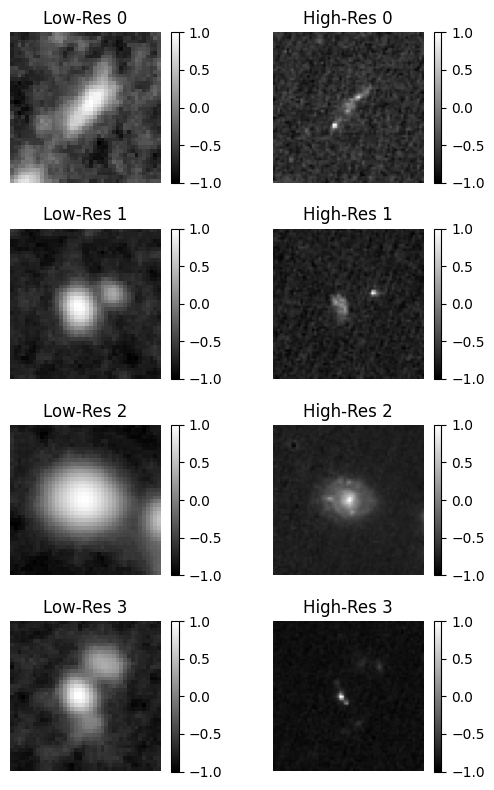

In [7]:
# Load Training Dataset (set split="train" explicitly)
train_dataset = SuperResolutionDataset(nisp_file, jwst_file, split="train")
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# Fetch a batch from the training dataset
lr_batch, hr_batch = next(iter(train_loader))

# Convert tensors to NumPy for visualization
lr_batch_np = lr_batch.squeeze().cpu().numpy()  
hr_batch_np = hr_batch.squeeze().cpu().numpy()  

# Plot first 4 samples
fig, axes = plt.subplots(4, 2, figsize=(6, 8))

for i in range(4):
    # Low-Res Image
    img1 = axes[i, 0].imshow(lr_batch_np[i], cmap='gray')
    axes[i, 0].set_title(f"Low-Res {i}")
    axes[i, 0].axis("off")
    fig.colorbar(img1, ax=axes[i, 0], fraction=0.046, pad=0.04)  # Add colorbar

    # High-Res Image
    img2 = axes[i, 1].imshow(hr_batch_np[i], cmap='gray')
    axes[i, 1].set_title(f"High-Res {i}")
    axes[i, 1].axis("off")
    fig.colorbar(img2, ax=axes[i, 1], fraction=0.046, pad=0.04)  # Add colorbar

plt.tight_layout()
plt.show()

In [8]:
# Use Mean Squared Error (MSE) Loss for Super-Resolution
criterion = nn.MSELoss()

# Define optimizer
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Number of epochs
num_epochs = 30

# Train-Test Dataloaders
train_loader = DataLoader(
    SuperResolutionDataset(nisp_file, jwst_file, split="train", sample_fraction=0.1),
    batch_size=128, shuffle=True, num_workers=8, pin_memory=True, persistent_workers=True
)

test_loader = DataLoader(
    SuperResolutionDataset(nisp_file, jwst_file, split="test"),
    batch_size=128, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True
)

# Training loop
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    start_time = time.time()

    print(f"Starting Epoch {epoch+1}...") 

    for batch_idx, (lr_batch, hr_batch) in enumerate(train_loader):

        lr_batch, hr_batch = lr_batch.to(device), hr_batch.to(device)
        t = torch.randint(0, model.diffusion.timesteps, (lr_batch.shape[0],), device=device)
        
        output = model(lr_batch, t)# Forward pass
        loss = criterion(output, hr_batch)# Compute loss
        epoch_loss += loss.item()
        
        optimizer.zero_grad()# Backpropagation
        loss.backward()
        optimizer.step()

    avg_loss = epoch_loss / len(train_loader)
    elapsed_time = time.time() - start_time

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.6f}, Time: {elapsed_time:.2f}s")

# Save trained model
torch.save(model.state_dict(), "super_resolution_model.pth")
print("Model saved successfully!")

Starting Epoch 1...


/tmp/ipykernel_921346/2163081123.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  lr_image = torch.tensor(lr_image, dtype=torch.float32)
/tmp/ipykernel_921346/2163081123.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  lr_image = torch.tensor(lr_image, dtype=torch.float32)
/tmp/ipykernel_921346/2163081123.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  lr_image = torch.tensor(lr_image, dtype=torch.float32)
/tmp/ipykernel_921346/2163081123.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTens

Epoch [1/30], Loss: 0.394977, Time: 7.45s
Starting Epoch 2...
Epoch [2/30], Loss: 0.084289, Time: 7.16s
Starting Epoch 3...
Epoch [3/30], Loss: 0.062283, Time: 7.14s
Starting Epoch 4...
Epoch [4/30], Loss: 0.058130, Time: 7.14s
Starting Epoch 5...
Epoch [5/30], Loss: 0.055055, Time: 7.14s
Starting Epoch 6...
Epoch [6/30], Loss: 0.051677, Time: 7.14s
Starting Epoch 7...
Epoch [7/30], Loss: 0.050113, Time: 7.15s
Starting Epoch 8...
Epoch [8/30], Loss: 0.047751, Time: 7.16s
Starting Epoch 9...
Epoch [9/30], Loss: 0.046813, Time: 7.15s
Starting Epoch 10...
Epoch [10/30], Loss: 0.045933, Time: 7.19s
Starting Epoch 11...
Epoch [11/30], Loss: 0.045288, Time: 7.15s
Starting Epoch 12...
Epoch [12/30], Loss: 0.043344, Time: 7.19s
Starting Epoch 13...
Epoch [13/30], Loss: 0.043750, Time: 7.15s
Starting Epoch 14...
Epoch [14/30], Loss: 0.043984, Time: 7.17s
Starting Epoch 15...
Epoch [15/30], Loss: 0.042590, Time: 7.16s
Starting Epoch 16...
Epoch [16/30], Loss: 0.042904, Time: 7.17s
Starting Epoch

# Evaluate (Shooby's code)

In [9]:
import torch
import wandb
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import random

# Load model
checkpoint_path = "super_resolution_model.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

unet = SuperResDiffusionUNet(in_channels=1, out_channels=1).to(device)
upsampler = Upsampler().to(device)
model = SuperResolutionDiffusion(unet, upsampler).to(device)

model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()

# Define DataLoader with num_workers for speed
test_loader = DataLoader(
    SuperResolutionDataset(nisp_file, jwst_file, split="test"),
    batch_size=16,  # Best balance
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    prefetch_factor=4,
    persistent_workers=True
)

/tmp/ipykernel_921346/2163081123.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  lr_image = torch.tensor(lr_image, dtype=torch.float32)
/tmp/ipykernel_921346/2163081123.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  lr_image = torch.tensor(lr_image, dtype=torch.float32)
/tmp/ipykernel_921346/2163081123.py:62: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  hr_image = torch.tensor(hr_image, dtype=torch.float32)
/tmp/ipykernel_921346/2163081123.py:62: UserWarning: To copy construct from a tensor, it is recommended to use sourceTens

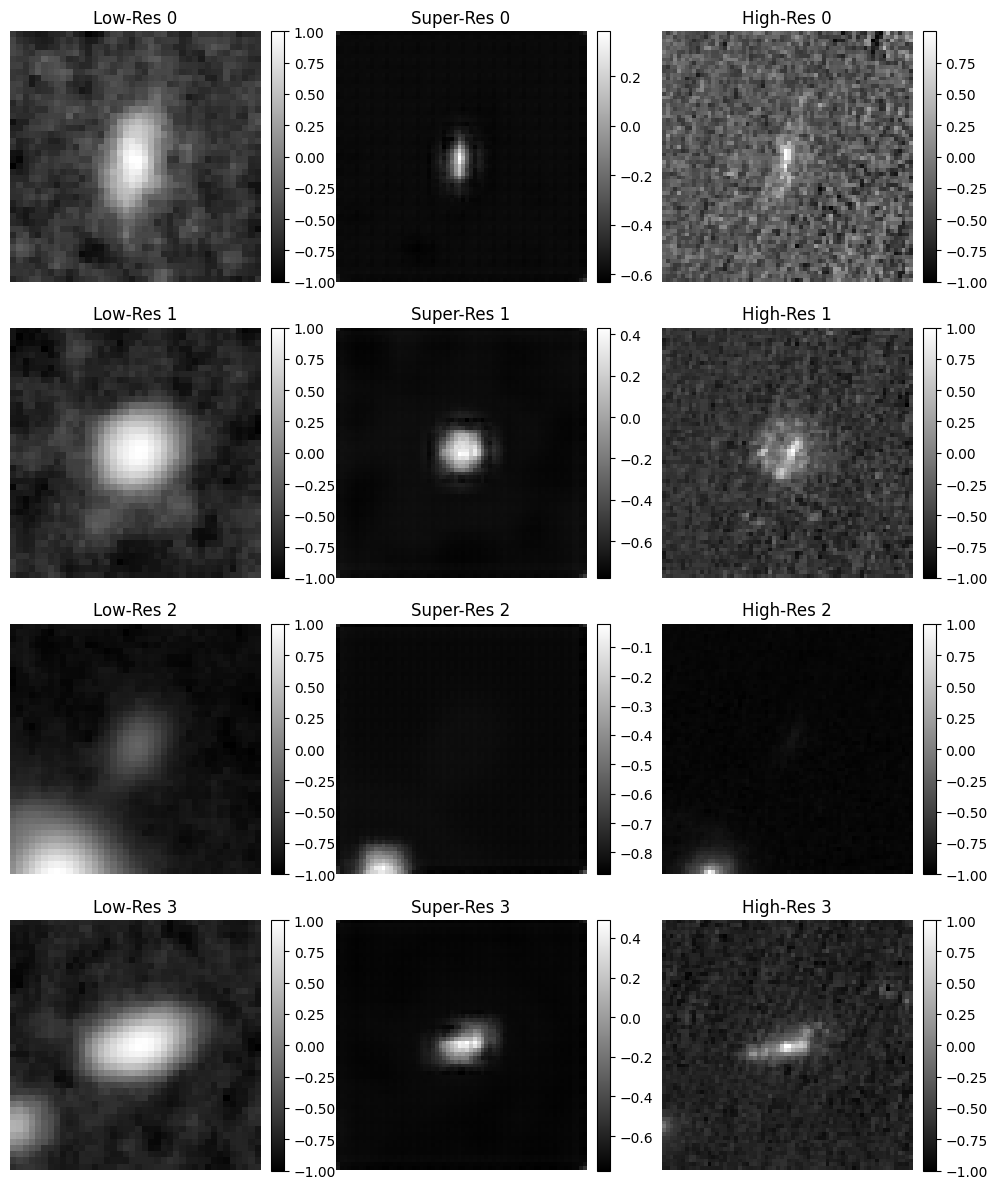

In [10]:
# Select a random batch **without loading all**
random_batch_idx = random.randint(0, len(test_loader) - 1)
for i, (lr_batch, hr_batch) in enumerate(test_loader):
    if i == random_batch_idx:
        break

lr_batch, hr_batch = lr_batch.to(device), hr_batch.to(device)

# Generate super-resolution images using AMP (faster)
with torch.no_grad(), torch.cuda.amp.autocast():
    t_test = torch.zeros((lr_batch.shape[0],), dtype=torch.long, device=device)  # t=0 for final reconstruction
    sr_batch = model(lr_batch, t_test).cpu()  # Move back to CPU

# Convert tensors to NumPy for visualization
lr_batch_np = lr_batch.cpu().squeeze().numpy()  
sr_batch_np = sr_batch.cpu().squeeze().numpy()  
hr_batch_np = hr_batch.cpu().squeeze().numpy()  

# Plot results
num_images = min(4, lr_batch.shape[0])
fig, axes = plt.subplots(num_images, 3, figsize=(10, 12))

for i in range(num_images):
    # Low-Resolution Image
    img1 = axes[i, 0].imshow(lr_batch_np[i], cmap='gray')
    axes[i, 0].set_title(f"Low-Res {i}")
    axes[i, 0].axis("off")
    fig.colorbar(img1, ax=axes[i, 0], fraction=0.046, pad=0.04)

    # Super-Resolved Image
    img2 = axes[i, 1].imshow(sr_batch_np[i], cmap='gray')
    axes[i, 1].set_title(f"Super-Res {i}")
    axes[i, 1].axis("off")
    fig.colorbar(img2, ax=axes[i, 1], fraction=0.046, pad=0.04)

    # High-Resolution Image (Ground Truth)
    img3 = axes[i, 2].imshow(hr_batch_np[i], cmap='gray')
    axes[i, 2].set_title(f"High-Res {i}")
    axes[i, 2].axis("off")
    fig.colorbar(img3, ax=axes[i, 2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [11]:
import time

for batch_size in [4, 8, 16, 32, 64]:  # Try different batch sizes
    test_loader = DataLoader(
        SuperResolutionDataset(nisp_file, jwst_file, split="test"),
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True,
        prefetch_factor=4,
        persistent_workers=True
    )

    start = time.time()
    lr_batch, hr_batch = next(iter(test_loader))
    end = time.time()

    print(f"Batch size {batch_size}: Data loading time = {end - start:.3f} seconds")

/tmp/ipykernel_921346/2163081123.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  lr_image = torch.tensor(lr_image, dtype=torch.float32)
/tmp/ipykernel_921346/2163081123.py:62: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  hr_image = torch.tensor(hr_image, dtype=torch.float32)
/tmp/ipykernel_921346/2163081123.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  lr_image = torch.tensor(lr_image, dtype=torch.float32)
/tmp/ipykernel_921346/2163081123.py:62: UserWarning: To copy construct from a tensor, it is recommended to use sourceTens

Batch size 4: Data loading time = 0.044 seconds


/tmp/ipykernel_921346/2163081123.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  lr_image = torch.tensor(lr_image, dtype=torch.float32)
/tmp/ipykernel_921346/2163081123.py:62: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  hr_image = torch.tensor(hr_image, dtype=torch.float32)
/tmp/ipykernel_921346/2163081123.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  lr_image = torch.tensor(lr_image, dtype=torch.float32)
/tmp/ipykernel_921346/2163081123.py:62: UserWarning: To copy construct from a tensor, it is recommended to use sourceTens

Batch size 8: Data loading time = 0.045 seconds


/tmp/ipykernel_921346/2163081123.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  lr_image = torch.tensor(lr_image, dtype=torch.float32)
/tmp/ipykernel_921346/2163081123.py:62: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  hr_image = torch.tensor(hr_image, dtype=torch.float32)
/tmp/ipykernel_921346/2163081123.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  lr_image = torch.tensor(lr_image, dtype=torch.float32)
/tmp/ipykernel_921346/2163081123.py:62: UserWarning: To copy construct from a tensor, it is recommended to use sourceTens

Batch size 16: Data loading time = 0.052 seconds


/tmp/ipykernel_921346/2163081123.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  lr_image = torch.tensor(lr_image, dtype=torch.float32)
/tmp/ipykernel_921346/2163081123.py:62: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  hr_image = torch.tensor(hr_image, dtype=torch.float32)
/tmp/ipykernel_921346/2163081123.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  lr_image = torch.tensor(lr_image, dtype=torch.float32)
/tmp/ipykernel_921346/2163081123.py:62: UserWarning: To copy construct from a tensor, it is recommended to use sourceTens

Batch size 32: Data loading time = 0.058 seconds


/tmp/ipykernel_921346/2163081123.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  lr_image = torch.tensor(lr_image, dtype=torch.float32)
/tmp/ipykernel_921346/2163081123.py:62: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  hr_image = torch.tensor(hr_image, dtype=torch.float32)
/tmp/ipykernel_921346/2163081123.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  lr_image = torch.tensor(lr_image, dtype=torch.float32)
/tmp/ipykernel_921346/2163081123.py:62: UserWarning: To copy construct from a tensor, it is recommended to use sourceTens

Batch size 64: Data loading time = 0.077 seconds


# With W and B

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
import wandb
from torch.utils.data import DataLoader
import random

def normalize_image(img):
    img = img.squeeze().cpu().numpy()
    img_min, img_max = img.min(), img.max()
    if img_max > img_min:
        img = (img - img_min) / (img_max - img_min)
    return (img * 255).astype("uint8")
    
# Initialize Weights & Biases
wandb.init(
    project="super-resolution-diffusion",
    config={
        "epochs": 50,
        "learning_rate": 1e-4,
        "batch_size": 64,  # Increased for better GPU utilization
        "optimizer": "AdamW",
        "loss_function": "MSELoss"
    }
)

# Enable CuDNN Optimization
torch.backends.cudnn.benchmark = True  

# Define loss function & optimizer
criterion = nn.MSELoss()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Instantiate & Move Model to GPU
unet = SuperResDiffusionUNet(in_channels=1, out_channels=1).to(device)
upsampler = Upsampler().to(device)
model = SuperResolutionDiffusion(unet, upsampler).to(device)

# Define optimizer
optimizer = optim.AdamW(model.parameters(), lr=wandb.config["learning_rate"], weight_decay=1e-5)

# Optimized Training DataLoader (Restored `num_workers=8`)
train_loader = DataLoader(
    SuperResolutionDataset(nisp_file, jwst_file, split="train", sample_fraction=0.1),
    batch_size=wandb.config["batch_size"],
    shuffle=True,
    num_workers=8,  # ✅ Restored 8 workers for fast training
    pin_memory=True, 
    persistent_workers=True  # ✅ Keeps workers alive for speed
)

# Optimized Test DataLoader (Restored `persistent_workers=True`)
test_loader = DataLoader(
    SuperResolutionDataset(nisp_file, jwst_file, split="test", sample_fraction=0.1),
    batch_size=wandb.config["batch_size"],
    shuffle=False,
    num_workers=2,  # ✅ Test set is smaller, 2 workers is enough
    pin_memory=True, 
    persistent_workers=True  # ✅ Restored to prevent slow reloading
)

# Enable Mixed Precision Training
scaler = torch.amp.GradScaler(device='cuda')  

# Training loop
num_epochs = wandb.config["epochs"]
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    start_time = time.time()

    for batch_idx, (lr_batch, hr_batch) in enumerate(train_loader):
        lr_batch, hr_batch = lr_batch.to(device, non_blocking=True), hr_batch.to(device, non_blocking=True)
        t = torch.randint(0, model.diffusion.timesteps, (lr_batch.shape[0],), device=device)

        optimizer.zero_grad()

        with torch.amp.autocast(device_type='cuda'):
            output = model(lr_batch, t)
            loss = criterion(output, hr_batch)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        torch.cuda.synchronize()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    elapsed_time = time.time() - start_time

    print(f"✅ Epoch {epoch + 1}/{num_epochs} completed in {elapsed_time:.2f} seconds. Loss: {avg_loss:.6f}")

    wandb.log({
        "epoch": epoch + 1,
        "train_loss": avg_loss,
        "time_per_epoch": elapsed_time,
        "gpu_usage": torch.cuda.memory_allocated(device) / 1e9,
        "gpu_max_allocated": torch.cuda.max_memory_allocated(device) / 1e9,
        "learning_rate": optimizer.param_groups[0]["lr"],
    })

    if (epoch + 1) % 5 == 0:
        model.eval()
        with torch.no_grad():
            # Select a random index from the dataset directly
            random_idx = random.randint(0, len(test_loader.dataset) - 1)    
            lr_img, hr_img = test_loader.dataset[random_idx]
            lr_img = lr_img.unsqueeze(0).to(device)  # Add batch dimension

            #Generate super-resolution image
            t_test = torch.zeros((1,), dtype=torch.long, device=device)
            sr_img = model(lr_img, t_test).cpu().squeeze(0)

            # Normalize images
            lr_img = normalize_image(lr_img)
            sr_img = normalize_image(sr_img)
            hr_img = normalize_image(hr_img)

            # Log to WandB
            wandb.log({
                "low_res": wandb.Image(lr_img, caption=f"Low-Res {random_idx}"),
                "super_res": wandb.Image(sr_img, caption=f"Super-Res {random_idx}"),
                "high_res": wandb.Image(hr_img, caption=f"High-Res {random_idx}"),
            })
        model.train()

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: eaev (eaev-uc-berkeley) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


/tmp/ipykernel_921346/2163081123.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  lr_image = torch.tensor(lr_image, dtype=torch.float32)
/tmp/ipykernel_921346/2163081123.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  lr_image = torch.tensor(lr_image, dtype=torch.float32)
/tmp/ipykernel_921346/2163081123.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  lr_image = torch.tensor(lr_image, dtype=torch.float32)
/tmp/ipykernel_921346/2163081123.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTens

✅ Epoch 1/50 completed in 5.16 seconds. Loss: 0.307281
✅ Epoch 2/50 completed in 4.18 seconds. Loss: 0.063969
✅ Epoch 3/50 completed in 4.17 seconds. Loss: 0.059329
✅ Epoch 4/50 completed in 4.18 seconds. Loss: 0.056031
✅ Epoch 5/50 completed in 4.15 seconds. Loss: 0.052656


/tmp/ipykernel_921346/2163081123.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  lr_image = torch.tensor(lr_image, dtype=torch.float32)
/tmp/ipykernel_921346/2163081123.py:62: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  hr_image = torch.tensor(hr_image, dtype=torch.float32)


✅ Epoch 6/50 completed in 4.19 seconds. Loss: 0.050610
✅ Epoch 7/50 completed in 4.17 seconds. Loss: 0.049000
✅ Epoch 8/50 completed in 4.17 seconds. Loss: 0.046996
✅ Epoch 9/50 completed in 4.17 seconds. Loss: 0.045379
✅ Epoch 10/50 completed in 4.19 seconds. Loss: 0.044942


/tmp/ipykernel_921346/2163081123.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  lr_image = torch.tensor(lr_image, dtype=torch.float32)
/tmp/ipykernel_921346/2163081123.py:62: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  hr_image = torch.tensor(hr_image, dtype=torch.float32)


✅ Epoch 11/50 completed in 4.18 seconds. Loss: 0.044934
✅ Epoch 12/50 completed in 4.16 seconds. Loss: 0.044061
✅ Epoch 13/50 completed in 4.16 seconds. Loss: 0.044509
✅ Epoch 14/50 completed in 4.16 seconds. Loss: 0.044979
✅ Epoch 15/50 completed in 4.17 seconds. Loss: 0.044340
✅ Epoch 16/50 completed in 4.18 seconds. Loss: 0.043956
✅ Epoch 17/50 completed in 4.17 seconds. Loss: 0.044024
✅ Epoch 18/50 completed in 4.18 seconds. Loss: 0.044110
✅ Epoch 19/50 completed in 4.18 seconds. Loss: 0.043697
✅ Epoch 20/50 completed in 4.18 seconds. Loss: 0.043234
✅ Epoch 21/50 completed in 4.18 seconds. Loss: 0.043771
✅ Epoch 22/50 completed in 4.17 seconds. Loss: 0.043718
✅ Epoch 23/50 completed in 4.16 seconds. Loss: 0.043434
✅ Epoch 24/50 completed in 4.17 seconds. Loss: 0.044009
✅ Epoch 25/50 completed in 4.19 seconds. Loss: 0.043120
✅ Epoch 26/50 completed in 4.17 seconds. Loss: 0.045249
✅ Epoch 27/50 completed in 4.18 seconds. Loss: 0.044035
✅ Epoch 28/50 completed in 4.17 seconds. Loss: 0

In [14]:
import torch
import wandb
import numpy as np
from torch.utils.data import DataLoader

# Initialize WandB
if wandb.run is None:
    wandb.init(project="super-resolution-diffusion-eval")

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load model
unet = SuperResDiffusionUNet(in_channels=1, out_channels=1).to(device)
upsampler = Upsampler().to(device)
model = SuperResolutionDiffusion(unet, upsampler).to(device)

checkpoint_path = "super_resolution_model.pth"
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()

# Define dataset and DataLoader
lr_hdf5_path = "../data/Nisp_train.hdf5"
hr_hdf5_path = "../data/Nircam_train.hdf5"
test_dataset = SuperResolutionDataset(nisp_file, jwst_file, split="test")
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2)

# Fetch a test batch
lr_batch, hr_batch = next(iter(test_loader))
lr_batch, hr_batch = lr_batch.to(device), hr_batch.to(device)

# Generate super-resolution (SR) images
with torch.no_grad():
    t_test = torch.zeros((lr_batch.shape[0],), dtype=torch.long, device=device)  # Set t=0 for final reconstruction
    sr_batch = model(lr_batch, t_test)

# Move tensors to CPU & detach
lr_batch = lr_batch.cpu().detach().numpy()
sr_batch = sr_batch.cpu().detach().numpy()
hr_batch = hr_batch.cpu().detach().numpy()

# Ensure batch size does not exceed available images
num_samples = min(4, lr_batch.shape[0])

# Convert to valid image range [0, 255] & prevent NaNs
def normalize_image(img):
    img = np.nan_to_num(img)  # Replace NaNs with 0
    img = (img - np.min(img, axis=(0, 1), keepdims=True)) / (np.ptp(img, axis=(0, 1), keepdims=True) + 1e-8)
    return (img * 255).astype(np.uint8)

# Prepare images for WandB
table = wandb.Table(columns=["Low-Res", "Super-Res", "High-Res"])
for i in range(num_samples):
    lr_img = normalize_image(lr_batch[i].squeeze())
    sr_img = normalize_image(sr_batch[i].squeeze())
    hr_img = normalize_image(hr_batch[i].squeeze())

    table.add_data(wandb.Image(lr_img, caption=f"Low-Res {i}"),
                   wandb.Image(sr_img, caption=f"Super-Res {i}"),
                   wandb.Image(hr_img, caption=f"High-Res {i}"))

# Log results to WandB
wandb.log({"Super-Resolution Results": table})

wandb.finish()

/tmp/ipykernel_921346/2163081123.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  lr_image = torch.tensor(lr_image, dtype=torch.float32)
/tmp/ipykernel_921346/2163081123.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  lr_image = torch.tensor(lr_image, dtype=torch.float32)
/tmp/ipykernel_921346/2163081123.py:62: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  hr_image = torch.tensor(hr_image, dtype=torch.float32)
/tmp/ipykernel_921346/2163081123.py:62: UserWarning: To copy construct from a tensor, it is recommended to use sourceTens

epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
gpu_max_allocated,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
gpu_usage,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
time_per_epoch,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,50
gpu_max_allocated,12.97055
gpu_usage,0.03613
learning_rate,0.0001
time_per_epoch,4.19372
